In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

df = pd.read_csv("spotify_artists.csv")

# Clean up column names (strip stray leading/trailing spaces, e.g. ' Artist Type')
df.columns = [c.strip() for c in df.columns]

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 500 rows, 14 columns


,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5   Artist Type                          500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

In [3]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Duplicate rows / duplicate artists
print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate artist names: {df['Artist Name'].duplicated().sum()}")

Missing values per column:
Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
Artist Type                            0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

Fully duplicated rows: 0
Duplicate artist names: 0


In [4]:
# Sanity check: does Solo + Collaborative streams add up to Total streams?
check = (df['Solo Streams (in millions)'] + df['Collaborative Streams (in millions)']
         - df['Total Streams (in millions)']).abs()
print("Max discrepancy between (Solo+Collab) and Total streams:", check.max())

# Sanity check: does Lead + Feature streams add up to Total streams?
check2 = (df['Lead Streams (in millions)'] + df['Feature Streams (in millions)']
          - df['Total Streams (in millions)']).abs()
print("Max discrepancy between (Lead+Feature) and Total streams:", check2.max())

df.describe().T

Max discrepancy between (Solo+Collab) and Total streams: 7.275957614183426e-12
Max discrepancy between (Lead+Feature) and Total streams: 89.19999999999891


,count,mean,std,min,25%,50%,75%,max
Debut Year,500.0,2005.346000,13.312578,1939.0,2001.750000,2009.000000,2014.000000,2023.0
Total Streams (in millions),500.0,16817.610200,14845.197632,6972.0,8768.175000,11923.250000,18020.050000,137492.1
Lead Streams (in millions),500.0,12141.734000,11844.675186,0.0,6489.750000,8716.350000,13456.900000,126177.3
Feature Streams (in millions),500.0,4681.289000,5952.827762,0.0,696.500000,3005.600000,6093.350000,43710.5
Solo Streams (in millions),500.0,8324.397600,9589.010168,0.0,2519.775000,6472.950000,10115.550000,113421.5
% of Solo Streams,500.0,50.613084,33.762147,0.0,20.117951,47.062829,83.139781,100.0
Collaborative Streams (in millions),500.0,8493.212600,9612.491536,0.0,2015.650000,6592.250000,11019.575000,84168.2
% of Collaborative Streams,500.0,49.386916,33.762147,0.0,16.860219,52.937171,79.882049,100.0


C:\Users\karth\AppData\Local\Temp\ipykernel_23736\1288764961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Sex", ax=axes[0], palette="viridis",
C:\Users\karth\AppData\Local\Temp\ipykernel_23736\1288764961.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Artist Type", ax=axes[1], palette="magma")
C:\Users\karth\AppData\Local\Temp\ipykernel_23736\1288764961.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_langs.values, y=top_langs.index, ax=axes[2], palette="crest")


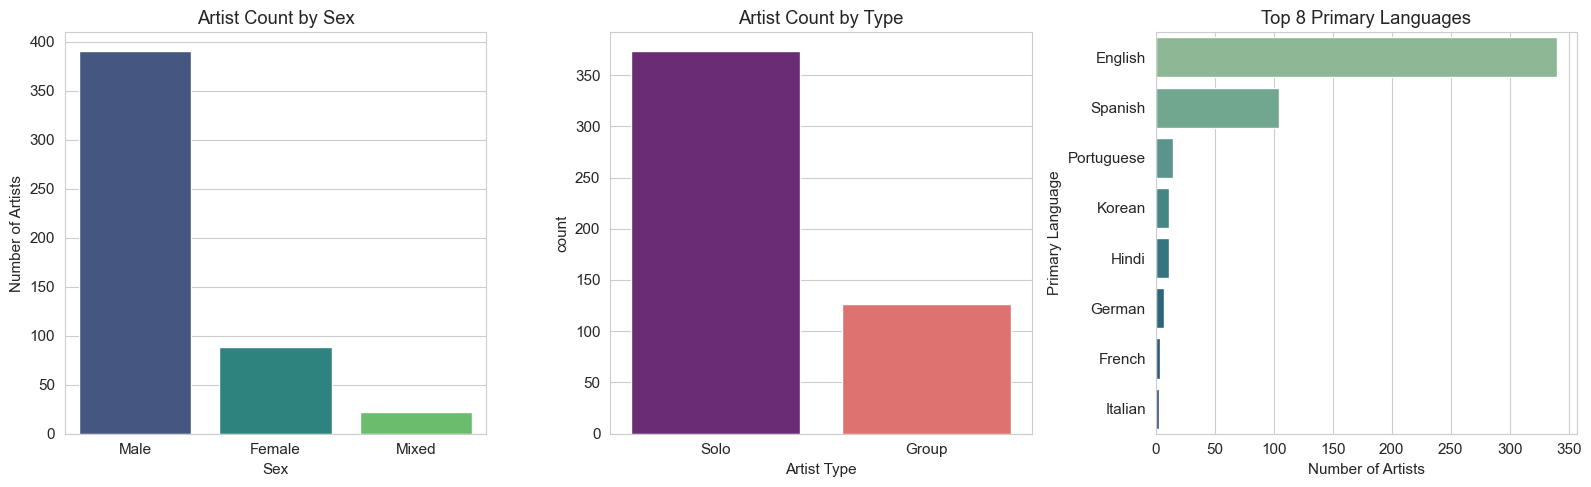

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x="Sex", ax=axes[0], palette="viridis",
              order=df["Sex"].value_counts().index)
axes[0].set_title("Artist Count by Sex")
axes[0].set_ylabel("Number of Artists")

sns.countplot(data=df, x="Artist Type", ax=axes[1], palette="magma")
axes[1].set_title("Artist Count by Type")

top_langs = df["Primary Language"].value_counts().head(8)
sns.barplot(x=top_langs.values, y=top_langs.index, ax=axes[2], palette="crest")
axes[2].set_title("Top 8 Primary Languages")
axes[2].set_xlabel("Number of Artists")

plt.tight_layout()
plt.show()

C:\Users\karth\AppData\Local\Temp\ipykernel_23736\3537936714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="flare")


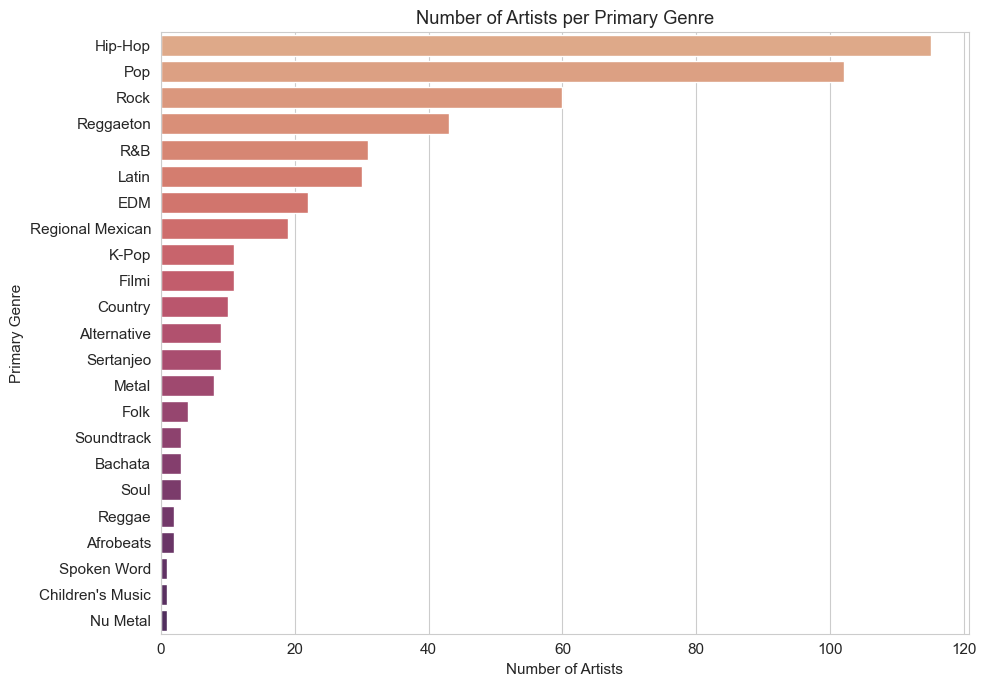

Number of unique genres: 23


In [6]:
genre_counts = df["Primary Genre"].value_counts()

plt.figure(figsize=(10, 7))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="flare")
plt.title("Number of Artists per Primary Genre")
plt.xlabel("Number of Artists")
plt.ylabel("Primary Genre")
plt.tight_layout()
plt.show()

print(f"Number of unique genres: {df['Primary Genre'].nunique()}")

C:\Users\karth\AppData\Local\Temp\ipykernel_23736\3455265900.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="mako")


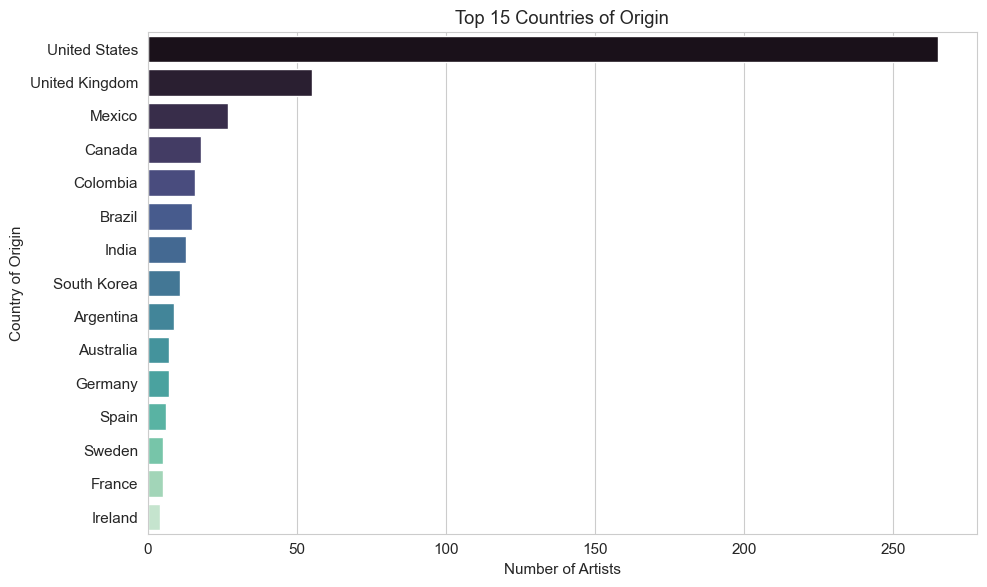

Total unique countries represented: 43


In [7]:
top_countries = df["Country of Origin"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="mako")
plt.title("Top 15 Countries of Origin")
plt.xlabel("Number of Artists")
plt.tight_layout()
plt.show()

print(f"Total unique countries represented: {df['Country of Origin'].nunique()}")

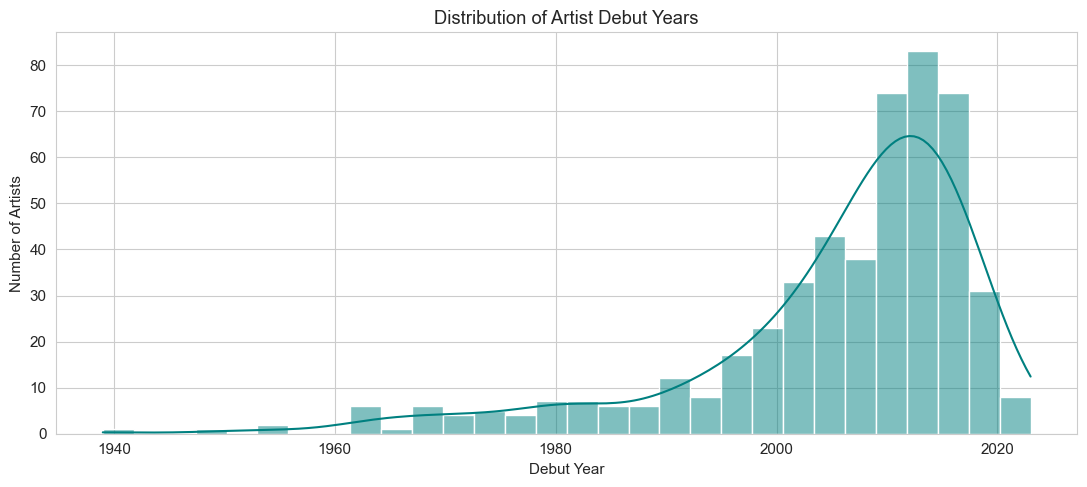

count     500.000000
mean     2005.346000
std        13.312578
min      1939.000000
25%      2001.750000
50%      2009.000000
75%      2014.000000
max      2023.000000
Name: Debut Year, dtype: float64


In [8]:
plt.figure(figsize=(11, 5))
sns.histplot(df["Debut Year"], bins=30, kde=True, color="teal")
plt.title("Distribution of Artist Debut Years")
plt.xlabel("Debut Year")
plt.ylabel("Number of Artists")
plt.tight_layout()
plt.show()

print(df["Debut Year"].describe())

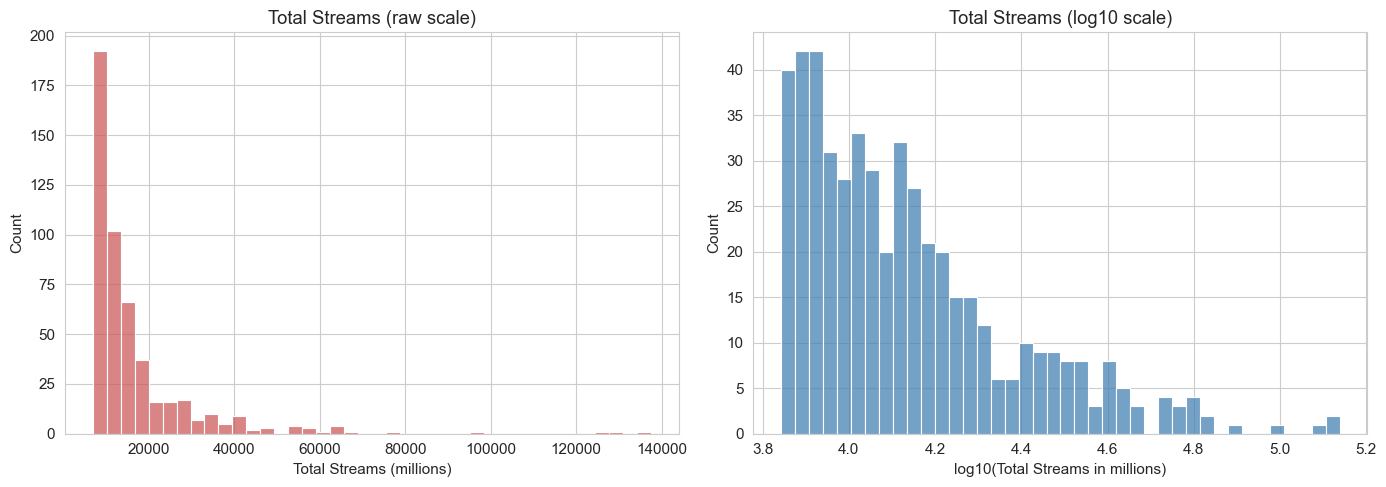

count       500.000000
mean      16817.610200
std       14845.197632
min        6972.000000
25%        8768.175000
50%       11923.250000
75%       18020.050000
max      137492.100000
Name: Total Streams (in millions), dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Total Streams (in millions)"], bins=40, color="indianred", ax=axes[0])
axes[0].set_title("Total Streams (raw scale)")
axes[0].set_xlabel("Total Streams (millions)")

sns.histplot(np.log10(df["Total Streams (in millions)"]), bins=40, color="steelblue", ax=axes[1])
axes[1].set_title("Total Streams (log10 scale)")
axes[1].set_xlabel("log10(Total Streams in millions)")

plt.tight_layout()
plt.show()

print(df["Total Streams (in millions)"].describe())

C:\Users\karth\AppData\Local\Temp\ipykernel_23736\3520389620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Sex", y="Total Streams (in millions)", palette="viridis")


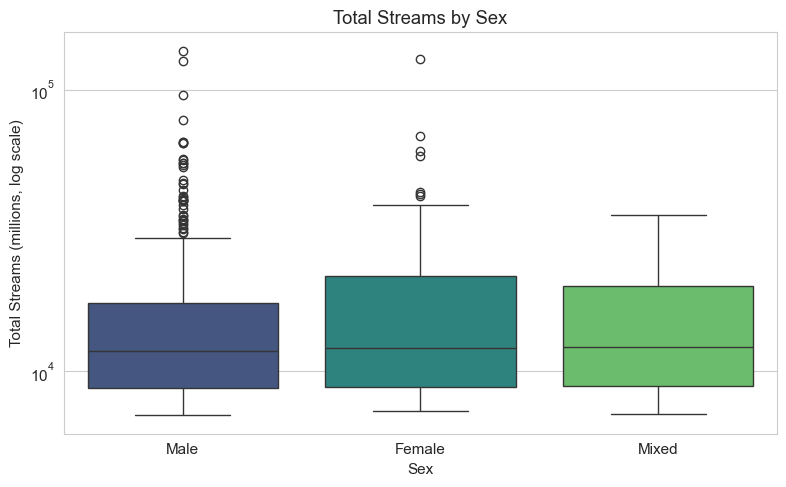

Sex
Mixed     12236.30
Female    12097.15
Male      11837.65
Name: Total Streams (in millions), dtype: float64

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Sex", y="Total Streams (in millions)", palette="viridis")
plt.title("Total Streams by Sex")
plt.yscale("log")
plt.ylabel("Total Streams (millions, log scale)")
plt.tight_layout()
plt.show()

df.groupby("Sex")["Total Streams (in millions)"].median().sort_values(ascending=False)

C:\Users\karth\AppData\Local\Temp\ipykernel_23736\3010412160.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x="Total Streams (in millions)", y="Primary Genre", order=order, palette="flare")


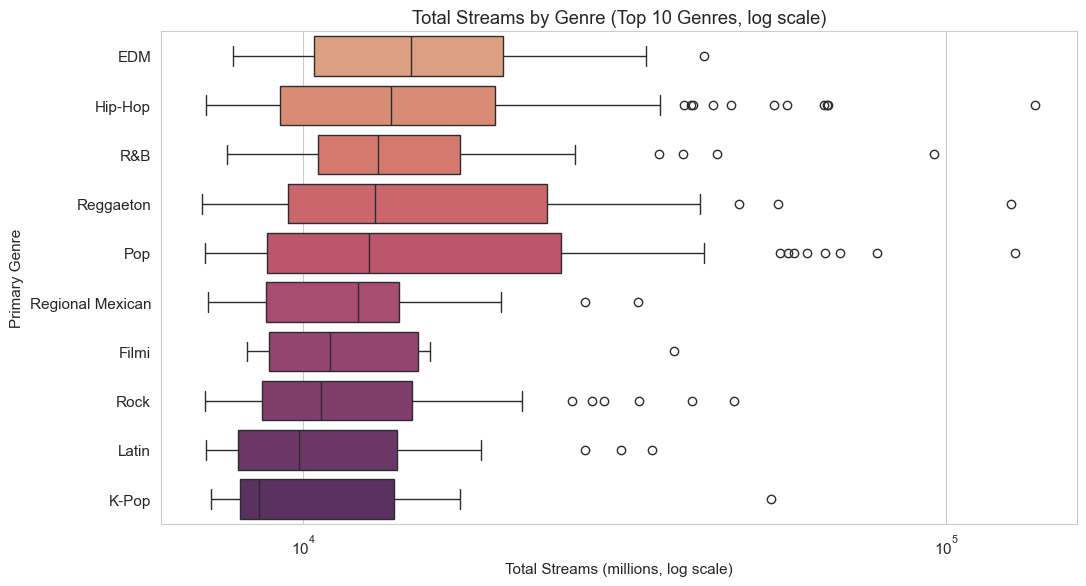

In [11]:
top10_genres = df["Primary Genre"].value_counts().head(10).index
subset = df[df["Primary Genre"].isin(top10_genres)]

order = subset.groupby("Primary Genre")["Total Streams (in millions)"].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 6))
sns.boxplot(data=subset, x="Total Streams (in millions)", y="Primary Genre", order=order, palette="flare")
plt.xscale("log")
plt.title("Total Streams by Genre (Top 10 Genres, log scale)")
plt.xlabel("Total Streams (millions, log scale)")
plt.tight_layout()
plt.show()

C:\Users\karth\AppData\Local\Temp\ipykernel_23736\2321553976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Artist Type", y="% of Solo Streams", palette="magma")


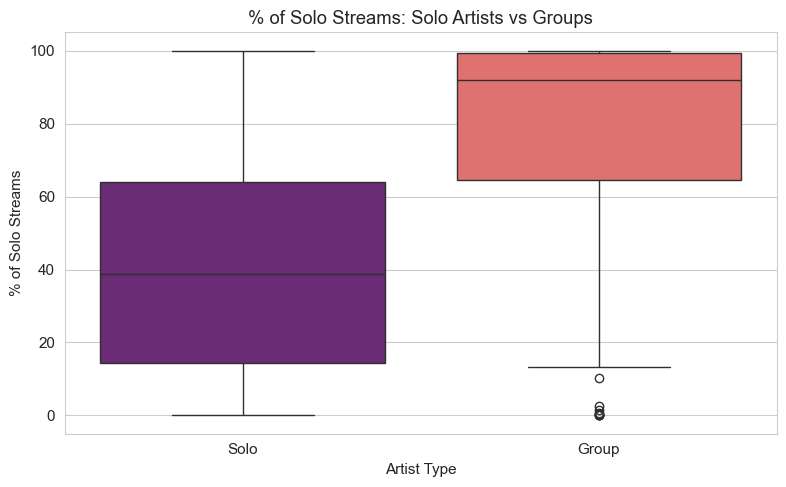

,count,mean,std,min,25%,50%,75%,max
Artist Type,,,,,,,,
Group,127.0,76.919996,30.874223,0.0,64.502139,92.042275,99.214361,100.0
Solo,373.0,41.656039,29.823851,0.0,14.354281,38.729941,64.034324,100.0


In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Artist Type", y="% of Solo Streams", palette="magma")
plt.title("% of Solo Streams: Solo Artists vs Groups")
plt.tight_layout()
plt.show()

df.groupby("Artist Type")["% of Solo Streams"].describe()

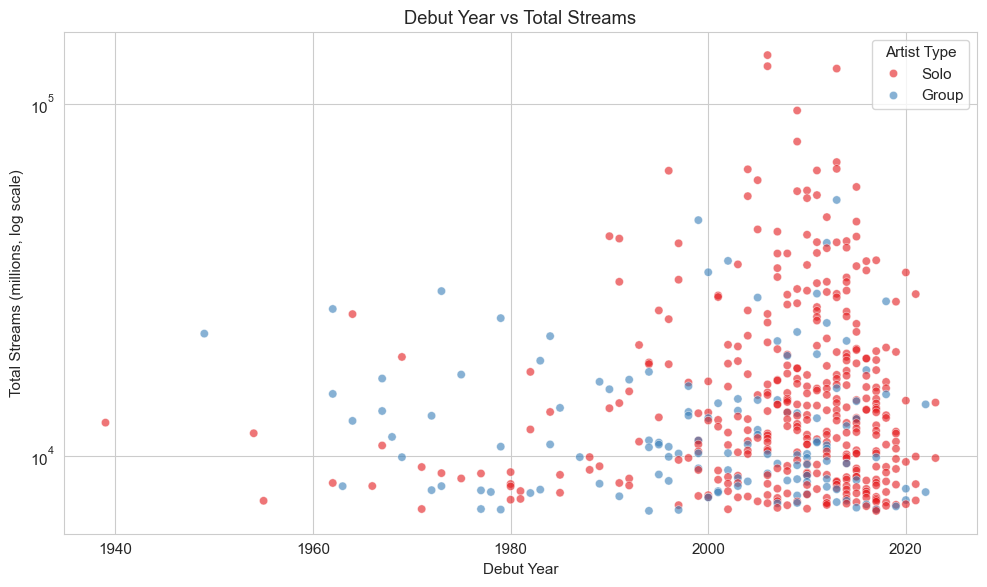

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Debut Year", y="Total Streams (in millions)",
                 hue="Artist Type", alpha=0.6, palette="Set1")
plt.yscale("log")
plt.title("Debut Year vs Total Streams")
plt.ylabel("Total Streams (millions, log scale)")
plt.tight_layout()
plt.show()

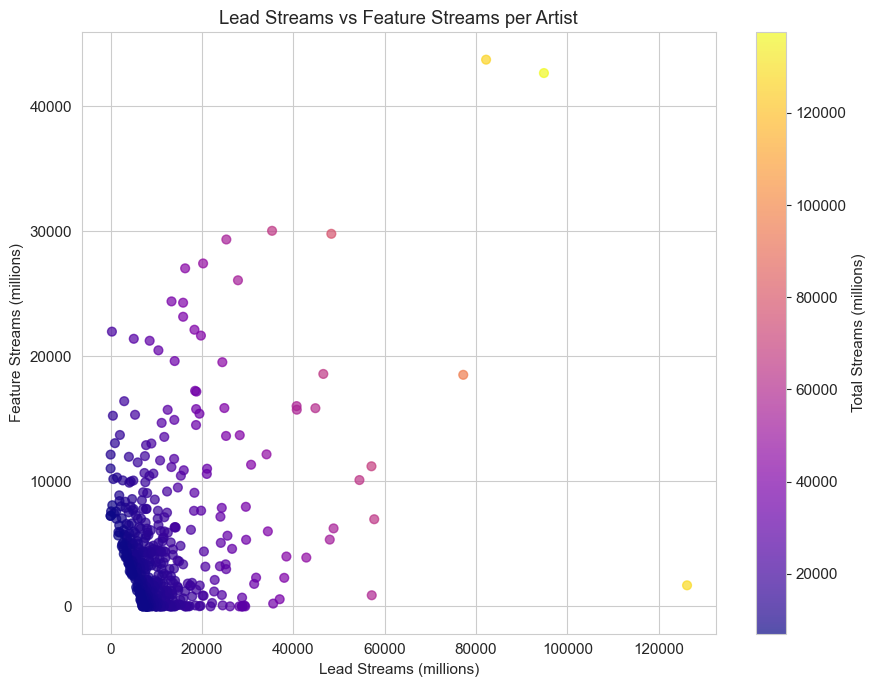

In [14]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(df["Lead Streams (in millions)"], df["Feature Streams (in millions)"],
                  c=df["Total Streams (in millions)"], cmap="plasma", alpha=0.7, s=40)
plt.colorbar(sc, label="Total Streams (millions)")
plt.xlabel("Lead Streams (millions)")
plt.ylabel("Feature Streams (millions)")
plt.title("Lead Streams vs Feature Streams per Artist")
plt.tight_layout()
plt.show()

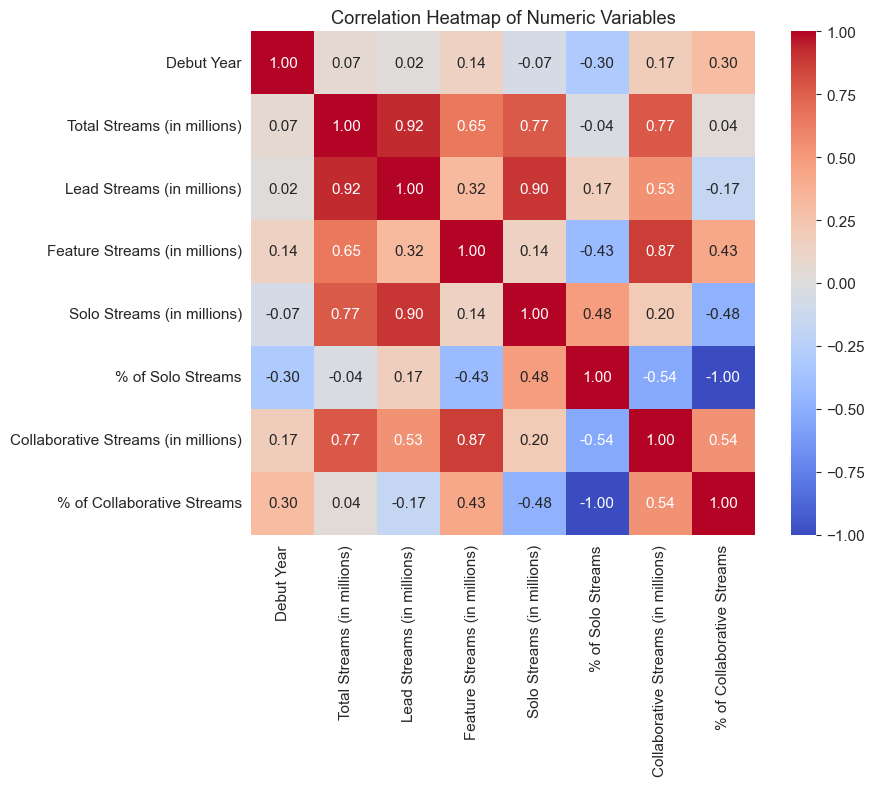

In [15]:
numeric_cols = ["Debut Year", "Total Streams (in millions)", "Lead Streams (in millions)",
                "Feature Streams (in millions)", "Solo Streams (in millions)",
                "% of Solo Streams", "Collaborative Streams (in millions)",
                "% of Collaborative Streams"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [16]:
top10_total = df.nlargest(10, "Total Streams (in millions)")[
    ["Artist Name", "Primary Genre", "Country of Origin", "Total Streams (in millions)"]
]
top10_total

,Artist Name,Primary Genre,Country of Origin,Total Streams (in millions)
0,Drake,Hip-Hop,Canada,137492.1
1,Taylor Swift,Pop,United States,127861.0
2,Bad Bunny,Reggaeton,United States,125899.8
3,The Weeknd,R&B,Canada,95703.2
4,Justin Bieber,Pop,Canada,78104.4
5,Ariana Grande,Pop,United States,68298.9
6,Travis Scott,Hip-Hop,United States,65349.7
7,Kanye West,Hip-Hop,United States,65142.9
8,Ed Sheeran,Pop,United Kingdom,64656.9
9,Eminem,Hip-Hop,United States,64549.0


C:\Users\karth\AppData\Local\Temp\ipykernel_23736\2084834598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_total, x="Total Streams (in millions)", y="Artist Name", palette="rocket")


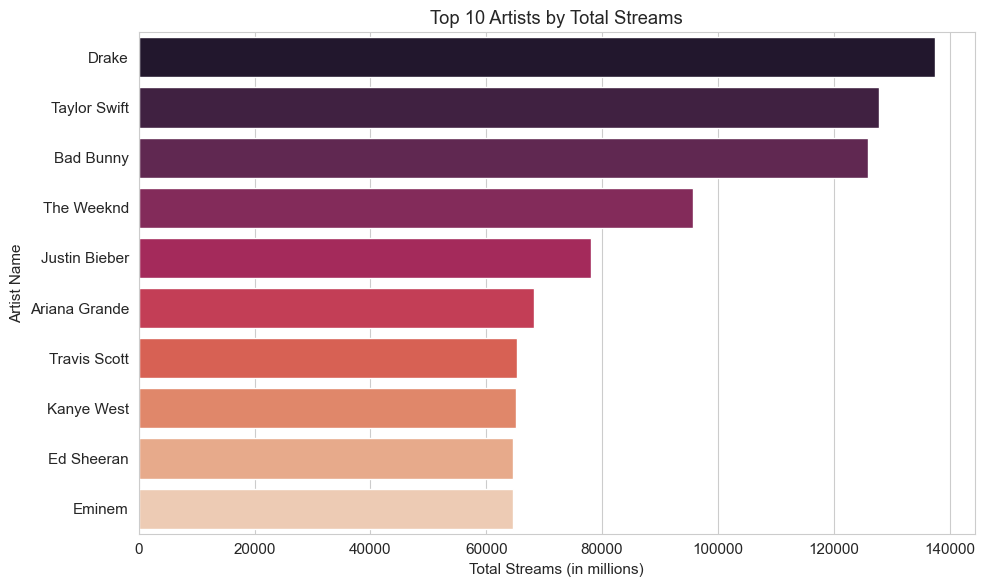

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top10_total, x="Total Streams (in millions)", y="Artist Name", palette="rocket")
plt.title("Top 10 Artists by Total Streams")
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 by % of Collaborative Streams (most collaboration-driven artists) among artists
# with substantial catalogs (Total Streams > 10,000M to avoid tiny-sample noise)
collab_leaders = df[df["Total Streams (in millions)"] > 10000].nlargest(
    10, "% of Collaborative Streams"
)[["Artist Name", "Primary Genre", "% of Collaborative Streams", "Total Streams (in millions)"]]
collab_leaders

,Artist Name,Primary Genre,% of Collaborative Streams,Total Streams (in millions)
89,Disney,Soundtrack,100.000000,22236.1
246,Amitabh Bhattacharya,Filmi,100.000000,12136.7
277,Irshad Kamil,Filmi,100.000000,11014.9
63,Pritam,Pop,99.959011,28543.9
256,MC Ryan SP,Hip-Hop,99.934273,11715.1
312,Vishal-Shekhar,Filmi,99.934088,10165.0
282,Tainy,Reggaeton,99.925915,10933.4
96,Diplo,EDM,99.842773,20670.8
217,Major Lazer,EDM,99.656591,13220.4
60,Metro Boomin,Hip-Hop,99.585077,28848.7


: 